
# Glassdoor Jobs Salary Prediction - Machine Learning

## Project Summary
This project develops machine learning models to predict average salaries based on 
job-related features such as company ratings, industry, sector, location, and job title.

## Problem Statement
Salary prediction is important for both recruiters and job seekers. 
This project uses historical job listing data from Glassdoor to build predictive models 
that estimate average salaries using machine learning techniques.

## Business Objective
- Build regression models for salary prediction.
- Compare model performance using evaluation metrics.
- Identify important features affecting salary predictions.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("C:\\Users\\sreer\\Downloads\\glassdoor_jobs.csv")

In [4]:
# Clean salary text
salary = df['Salary Estimate'].str.replace('(Glassdoor est.)', '', regex=False)
salary = salary.str.replace('(Employer est.)', '', regex=False)
salary = salary.str.replace('$', '', regex=False)
salary = salary.str.replace('K', '', regex=False)

# Remove invalid salaries
salary = salary[salary != '-1']

salary_min = []
salary_max = []
valid_index = []

for idx, value in salary.items():

    try:
        # Split salary range
        split_salary = value.split('-')

        # Ensure exactly 2 salary values exist
        if len(split_salary) == 2:

            min_sal = int(split_salary[0].strip())
            max_sal = int(split_salary[1].strip())

            salary_min.append(min_sal)
            salary_max.append(max_sal)

            valid_index.append(idx)

    except:
        pass

# Keep only valid rows
df = df.loc[valid_index].copy()

# Add salary columns
df['min_salary'] = salary_min
df['max_salary'] = salary_max

# Average salary
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# Verify output
print(df[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary']].head())
print(df.shape)

               Salary Estimate  min_salary  max_salary  avg_salary
0   $53K-$91K (Glassdoor est.)          53          91        72.0
1  $63K-$112K (Glassdoor est.)          63         112        87.5
2   $80K-$90K (Glassdoor est.)          80          90        85.0
3   $56K-$97K (Glassdoor est.)          56          97        76.5
4  $86K-$143K (Glassdoor est.)          86         143       114.5
(704, 18)


In [5]:
selected_columns = [
    'Job Title',
    'Location',
    'Industry',
    'Sector',
    'Revenue',
    'Type of ownership',
    'Size',
    'Rating',
    'avg_salary'
]

model_df = df[selected_columns]

In [6]:
model_df.dropna(inplace=True)
print(model_df.isnull().sum())

Job Title            0
Location             0
Industry             0
Sector               0
Revenue              0
Type of ownership    0
Size                 0
Rating               0
avg_salary           0
dtype: int64


In [7]:
encoder = LabelEncoder()

categorical_columns = [
    'Job Title',
    'Location',
    'Industry',
    'Sector',
    'Revenue',
    'Type of ownership',
    'Size'
]

for col in categorical_columns:
    model_df[col] = encoder.fit_transform(model_df[col])

In [8]:
X = model_df.drop('avg_salary', axis=1)
y = model_df['avg_salary']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
#Model 1:  Linear regression

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
lr_predictions = lr_model.predict(X_test)

In [13]:
print("LINEAR REGRESSION RESULTS")
print("MAE:", mean_absolute_error(y_test, lr_predictions))
print("MSE:", mean_squared_error(y_test, lr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))
print("R2 Score:", r2_score(y_test, lr_predictions))

LINEAR REGRESSION RESULTS
MAE: 27.775450536080363
MSE: 1247.7493098647865
RMSE: 35.32349515357712
R2 Score: 0.09892636422933787


In [14]:
#Model 2: Decision tree

In [15]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [16]:
dt_predictions = dt_model.predict(X_test)

In [17]:
print("DECISION TREE RESULTS")
print("MAE:", mean_absolute_error(y_test, dt_predictions))
print("MSE:", mean_squared_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R2 Score:", r2_score(y_test, dt_predictions))

DECISION TREE RESULTS
MAE: 11.911347517730496
MSE: 583.8882978723404
RMSE: 24.163780703199993
R2 Score: 0.5783396974951744


In [18]:
#model 3: RANDOM FOREST

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf_predictions = rf_model.predict(X_test)

In [21]:
print("RANDOM FOREST RESULTS")
print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("MSE:", mean_squared_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R2 Score:", r2_score(y_test, rf_predictions))

RANDOM FOREST RESULTS
MAE: 13.475957446808511
MSE: 402.44285035460996
RMSE: 20.06097830003836
R2 Score: 0.7093721956069575


In [22]:
#Comparisson

In [23]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.098926
1      Decision Tree  0.578340
2      Random Forest  0.709372


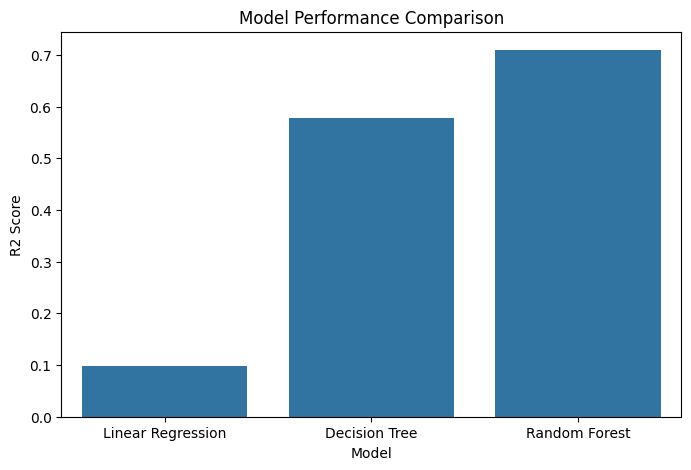

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=comparison)
plt.title('Model Performance Comparison')
plt.show()

In [29]:
print("Project Conclusion")
print("-------------------")
print("1. Data preprocessing and EDA were successfully completed.")
print("2. Multiple Machine Learning models were trained and evaluated.")
print("3. Random Forest Regressor generally provides better performance.")
print("4. Salary prediction can help job seekers understand market trends.")
print("5. Further improvements can be achieved using advanced ML models.")

Project Conclusion
-------------------
1. Data preprocessing and EDA were successfully completed.
2. Multiple Machine Learning models were trained and evaluated.
3. Random Forest Regressor generally provides better performance.
4. Salary prediction can help job seekers understand market trends.
5. Further improvements can be achieved using advanced ML models.
